# Simulacion con modelo de Jensen

In [24]:
%pip install pvlib
%pip install matplotlib
%pip install seaborn
%pip install calendar

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement calendar (from versions: none)
ERROR: No matching distribution found for calendar


In [40]:
import pvlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import calendar

In [66]:
# Configuracion basica

lat, lon = 19.4789135, -96.9500014 # Coordenadas de streger veracruz.
tz = 'America/Mexico_City'
height = 1400 # Altura promedio Jalapa veracruz. sobre el nivel del mar. 
tiempos = pd.date_range(start='2026-12-21 00:00', end = '2027-12-20 23:59', freq='15min', tz=tz)

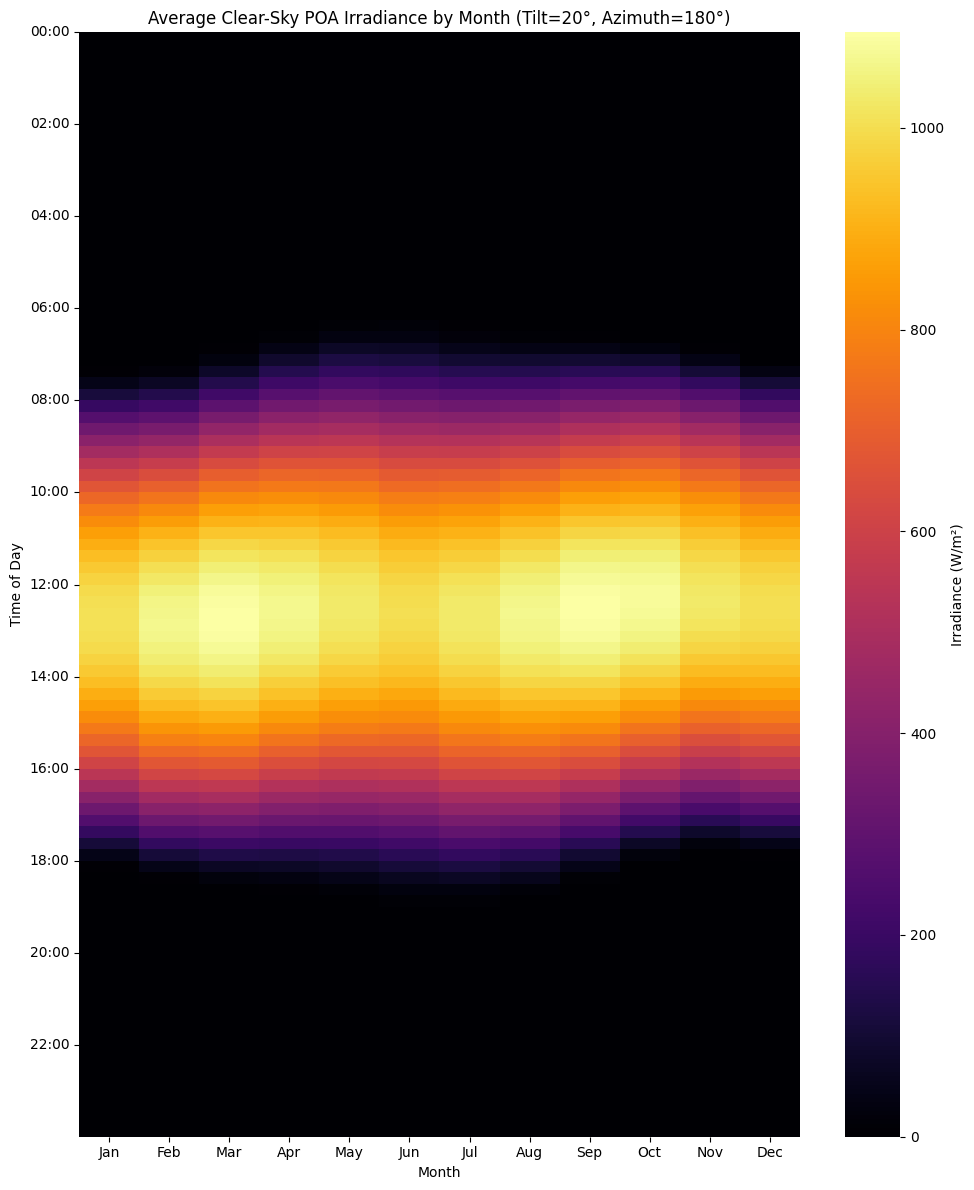

Irradiancia máxima anual: 1099.38 W/m²


In [72]:
# Crear el objeto Location automatiza muchos calculos fisicos y atmosfericos
loc = pvlib.location.Location(lat, lon, tz=tz, altitude=height)

# 2. Posicion solar
sol = loc.get_solarposition(tiempos)

# 3. Modelo de cielo despejado
# get_clearsky calcula la masa de aire correcta para CADA intervalo de 15 min.
clearsky = loc.get_clearsky(tiempos)

# 4. Transposicion (Calculo del panel)
# Cambiamos el surface_tilt a 20 (aprox la latitud) para ver el efecto de apuntar al Sur
irradiance_total = pvlib.irradiance.get_total_irradiance(
    surface_tilt=20, 
    surface_azimuth=180,
    solar_zenith=sol['apparent_zenith'],
    solar_azimuth=sol['azimuth'],
    dni=clearsky['dni'],
    ghi=clearsky['ghi'],
    dhi=clearsky['dhi']
)

# 5. Hacer matriz de irradiancia
df = pd.DataFrame({
    'poa_global': irradiance_total['poa_global'],
    'month': tiempos.month,
    'time': tiempos.time
})

heatmap_data = df.pivot_table(index='time', columns='month', values='poa_global', aggfunc='mean')
heatmap_data.columns = [calendar.month_abbr[i] for i in heatmap_data.columns]

plt.figure(figsize=(10, 12))
ax = sns.heatmap(heatmap_data, cmap='inferno', cbar_kws={'label': 'Irradiance (W/m²)'})

# Limpiar las etiquetas del eje Y para que sean legibles
yticks = heatmap_data.index
plt.yticks(np.arange(0, 96, 8), [t.strftime('%H:%M') for t in yticks[::8]], rotation=0)

plt.title('Average Clear-Sky POA Irradiance by Month (Tilt=20°, Azimuth=180°)')
plt.xlabel('Month')
plt.ylabel('Time of Day')
plt.tight_layout()

plt.show()

print(f'Irradiancia máxima anual: {irradiance_total["poa_global"].max():.2f} W/m²')

In [ ]:
# 2. Posicion solar

sol = pvlib.solarposition.get_solarposition(tiempos, lat, lon)
zenith_vals = sol['apparent_zenith'].values
azimuth_vals = sol['azimuth'].values

# 3. Modelo de cielo despejado
clearsky = pvlib.clearsky.ineichen(zenith_vals, airmass_absolute=1.5 linke_turbidity=3, altitude=500)

# 4. Transposicion (Calculo del panel)
irradiance_total = pvlib.irradiance.get_total_irradiance(
    surface_tilt = 0,
    surface_azimuth=180,
    solar_zenith=zenith_vals,
    solar_azimuth = azimuth_vals,
    dni = clearsky['dni'],
    ghi = clearsky['ghi'],
    dhi = clearsky['dhi']
)


TypeError: ineichen() missing 1 required positional argument: 'airmass_absolute'

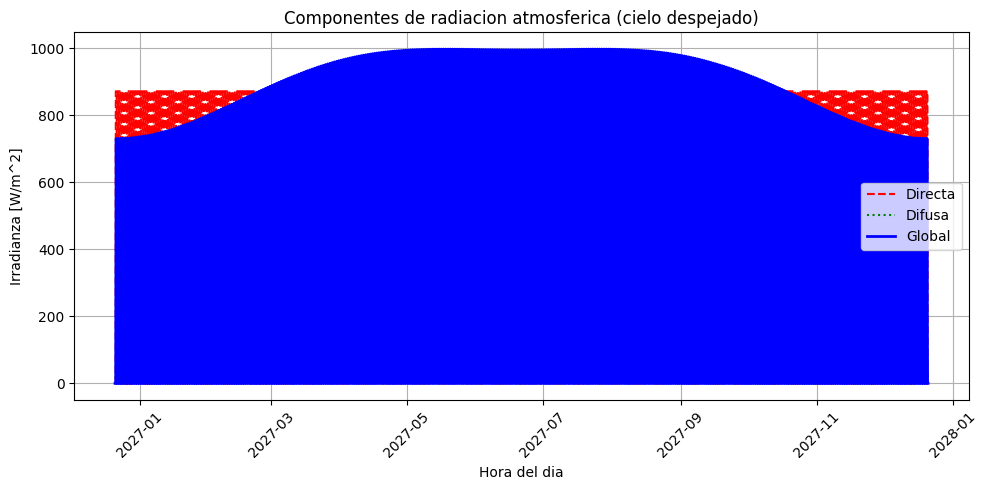

In [51]:
# Grafica de componentes atmosfericos

plt.figure(figsize=(10,5))
plt.plot(tiempos, clearsky['dni'], label = 'Directa', color = 'red', linestyle = '--')
plt.plot(tiempos, clearsky['dhi'], label = 'Difusa', color = 'green', linestyle = ':')
plt.plot(tiempos, clearsky['ghi'], label = 'Global', color = 'blue', linewidth = 2)

plt.title('Componentes de radiacion atmosferica (cielo despejado)')
plt.xlabel('Hora del dia')
plt.ylabel('Irradianza [W/m^2]')
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Imprimir resumen de consola



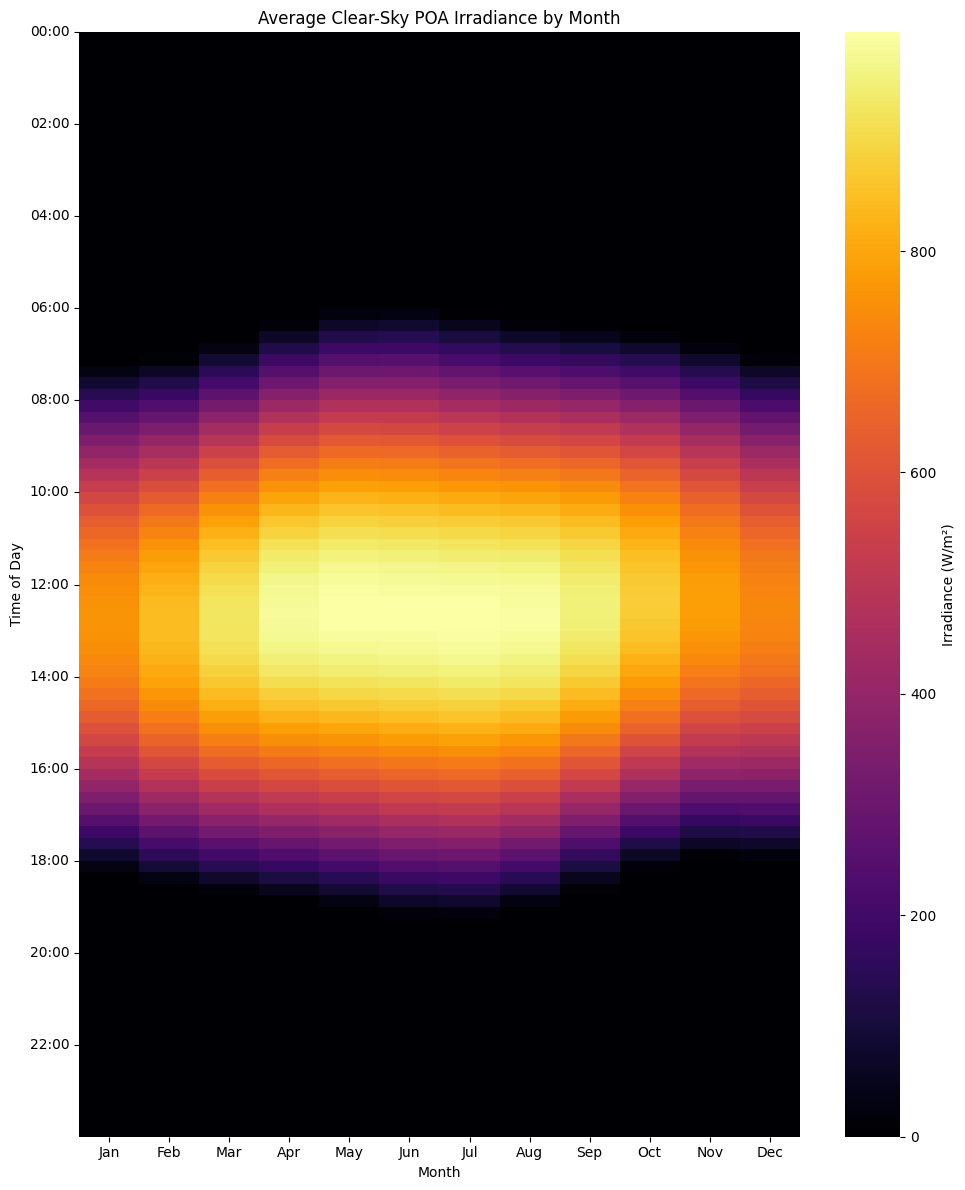

Irradiancia máxima anual: 998.21 W/m²


In [69]:
# Hacer matriz de irradianza


df = pd.DataFrame({
    'poa_global': irradiance_total['poa_global'],
    'month': tiempos.month,
    'time': tiempos.time
})


heatmap_data = df.pivot_table(index='time', columns='month', values='poa_global', aggfunc='mean')

heatmap_data.columns = [calendar.month_abbr[i] for i in heatmap_data.columns]

plt.figure(figsize=(10, 12))

ax = sns.heatmap(heatmap_data, cmap='inferno', cbar_kws={'label': 'Irradiance (W/m²)'})

yticks = heatmap_data.index
plt.yticks(np.arange(0, 96, 8), [t.strftime('%H:%M') for t in yticks[::8]], rotation=0)

plt.title('Average Clear-Sky POA Irradiance by Month')
plt.xlabel('Month')
plt.ylabel('Time of Day')
plt.tight_layout()

plt.show()

print(f'Irradiancia máxima anual: {irradiance_total["poa_global"].max():.2f} W/m²')

## Grafica de demanda

            Fecha_Hora  Demanda_kW  Factor_Potencia
0  2025-12-21 00:00:00   21.590029         0.833231
1  2025-12-21 00:15:00   21.776482         0.866455
2  2025-12-21 00:30:00   20.688577         0.831310
3  2025-12-21 00:45:00   22.926434         0.851338
4  2025-12-21 01:00:00   20.398915         0.846837


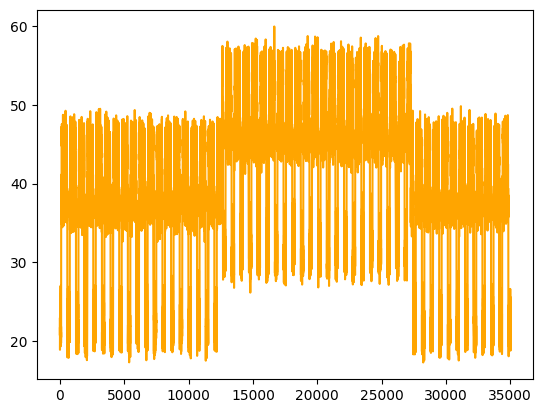

In [ ]:
df_ejemplo = pd.read_csv('demanda_ejemplo.csv')

print(df_ejemplo.head())

plt.plot(df_ejemplo['Demanda_kW'], label='Demanda', color='orange')
plt.show()